# Theme Gallery

Each predefined theme has a card here: a strip of its color swatches with hex
codes, the sequential and diverging colormaps, and the font it sets in, its
colour-blindness scores, and the same
six signature charts rendered under that theme — grouped bars, lines, a fitted
scatter, a box plot, a heatmap, and a twin-axis [`Panel`](../../utility/panel/). The six charts cover
every trait a theme can differ in: palette, edges and fills, line strokes and
markers, bodies, value scales, and the furniture around them (spines, grid,
ticks, legend). The themes are grouped by where they work best:

<table>
<thead><tr><th>Theme</th><th>Character</th></tr></thead>
<tbody><tr><td colspan="2" style="font-weight: 700"><a href="#screen-and-presentations">Screen and presentations</a></td></tr>
<tr><td style="white-space: nowrap"><a href="#default"><code>THEME.DEFAULT</code></a></td><td>Softened Okabe–Ito palette, colour-blind safe, open spines, soft grid.</td></tr>
<tr><td style="white-space: nowrap"><a href="#material"><code>THEME.MATERIAL</code></a></td><td>Google hues re-stepped for deutan readers, bottom spine only, light grid.</td></tr>
<tr><td style="white-space: nowrap"><a href="#minimal"><code>THEME.MINIMAL</code></a></td><td>Accent violet with five stepped greys, no spines, flat bars.</td></tr>
<tr><td style="white-space: nowrap"><a href="#harbor"><code>THEME.HARBOR</code></a></td><td>Navy and amber in lightness steps, colour-blind safe.</td></tr>
<tr><td style="white-space: nowrap"><a href="#dark"><code>THEME.DARK</code></a></td><td>Bright marks on a near-black page, light furniture, Viridis value scale.</td></tr>
</tbody>
<tbody><tr><td colspan="2" style="font-weight: 700"><a href="#print-and-black-and-white">Print and black-and-white</a></td></tr>
<tr><td style="white-space: nowrap"><a href="#greyscale"><code>THEME.GREYSCALE</code></a></td><td>Five greys with hatch, dash and marker cycles, print-friendly.</td></tr>
<tr><td style="white-space: nowrap"><a href="#ink"><code>THEME.INK</code></a></td><td>Lightness-stepped YlGnBu palette with navy ink accents.</td></tr>
<tr><td style="white-space: nowrap"><a href="#hatch"><code>THEME.HATCH</code></a></td><td>Six-entry hatch cycle, black edges, dotted grid.</td></tr>
<tr><td style="white-space: nowrap"><a href="#muted"><code>THEME.MUTED</code></a></td><td>Tol's muted colours, dash and marker cycles, colour-blind safe.</td></tr>
<tr><td style="white-space: nowrap"><a href="#contrast"><code>THEME.CONTRAST</code></a></td><td>Lightness-stepped colours plus hatches, print-safe.</td></tr>
<tr><td style="white-space: nowrap"><a href="#muted-hatch"><code>THEME.MUTEDHATCH</code></a></td><td>Tol's muted colours under hatches, BuPu value scale.</td></tr>
<tr><td style="white-space: nowrap"><a href="#slate-hatch"><code>THEME.SLATEHATCH</code></a></td><td>The hatch theme without rust: slate blue first, PuBu value scale.</td></tr>
</tbody>
<tbody><tr><td colspan="2" style="font-weight: 700"><a href="#illustrative">Illustrative</a></td></tr>
<tr><td style="white-space: nowrap"><a href="#sketch"><code>THEME.SKETCH</code></a></td><td>Hand-drawn wobble and halo, Comic Neue font, no grid.</td></tr>
<tr><td style="white-space: nowrap"><a href="#quill"><code>THEME.QUILL</code></a></td><td>Black ink on white paper: pen strokes, etched fills, IM Fell English font.</td></tr>
</tbody>
</table>

Themes also carry *defaults for chart settings*: every theme but `SKETCH` and
`QUILL` shows a muted y-grid unless a chart call sets `show_grid` itself, and
`HATCH` hatches bar series via its hatch cycle, which is why the very same
chart code below renders with grids and hatches that differ per theme. An
explicit setting always wins.

A theme with a different hue is not a new card: `derive_theme` in the
[Themes guide](../themes/#deriving-a-theme-from-a-colormap) rebuilds any
theme's palettes from a colormap in
[COLORS](../../../references/constants/#datachart.constants.COLORS) and keeps
its furniture.

In [1]:
import math
import random

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from datachart.charts import BarChart, BoxPlot, Heatmap, LineChart, ScatterChart
from datachart.config import config
from datachart.constants import THEME
from datachart.utils import Grid, Panel
from datachart.themes import score_palette
from datachart.themes.score import palette_colors
from datachart.utils._internal.colors import get_discrete_colors

random.seed(42)
FIGSIZE = (4.2, 3.0)


def ema(vals, alpha=0.35):
    out, acc = [], vals[0]
    for v in vals:
        acc = alpha * v + (1 - alpha) * acc
        out.append(acc)
    return out


CATS = ["Bench A", "Bench B", "Bench C", "Bench D"]
GROUPED = [
    [{"label": c, "y": y} for c, y in zip(CATS, [66.7, 58.6, 76.7, 83.2])],
    [{"label": c, "y": y} for c, y in zip(CATS, [65.4, 57.7, 77.8, 82.7])],
    [{"label": c, "y": y} for c, y in zip(CATS, [68.5, 53.4, 76.9, 85.9])],
]

LINES = [
    [
        {"x": x, "y": 40 + 18 * math.sin(x / 3.2) + x * k + random.uniform(-2, 2)}
        for x in range(0, 21)
    ]
    for k in (1.6, 0.9, 0.3)
]

# Regression scatter: noisy linear data, fitted line + CI drawn by the chart
REG = [
    {"x": x, "y": 12 + 1.8 * x + random.gauss(0, 4.5)}
    for x in [random.uniform(0, 20) for _ in range(70)]
]

# Box plot: score distributions per release (long form)
BOX = [
    {"label": g, "value": random.gauss(mu, sd)}
    for g, mu, sd in (
        ("v1.0", 62, 6),
        ("v1.1", 68, 5),
        ("v2.0", 74, 7),
        ("v2.1", 71, 4),
    )
    for _ in range(60)
]

HEAT = {
    "z": [
        [
            round(abs(math.sin(0.5 * i + 0.8 * j)) * (1 - 0.07 * abs(i - j)), 2)
            for j in range(6)
        ]
        for i in range(6)
    ],
}

# Training: noisy loss + smoothed trend (left), validation accuracy (right)
EPOCHS = list(range(1, 31))
TRAIN_LOSS = [
    2.5 * math.exp(-e / 8) + 0.4 + random.uniform(-0.08, 0.08) for e in EPOCHS
]
LOSS_TREND = ema(TRAIN_LOSS)
VAL_ACC = [
    50 + 38 * (1 - math.exp(-e / 10)) + random.uniform(-1.2, 1.2) for e in EPOCHS
]
VAL_TREND = ema(VAL_ACC)


SWATCH_CSS = """
<style>
.theme-swatches { display: flex; flex-wrap: wrap; gap: .6em 1em; align-items: flex-end;
  margin: .4em 0 .6em; font-size: .75em; }
.theme-scores { font-size: .85em; margin: 0 0 1em; }
.theme-swatches .swatch { display: flex; flex-direction: column; align-items: center; gap: .3em; }
.theme-swatches .swatch > span { display: block; width: 2.6em; height: 2.6em;
  border-radius: .3em; box-shadow: inset 0 0 0 1px rgba(0,0,0,.12); }
.theme-swatches .swatch > code { font-size: .85em; background: none; padding: 0; }
.theme-swatches .scale > span { width: 9em; }
.theme-swatches .font > span { width: auto; height: auto; min-width: 2.6em; padding: 0 .4em;
  box-shadow: none; font-size: 1.6em; line-height: 1.625; }
.theme-swatches .divider { align-self: stretch; width: 1px; background: rgba(128,128,128,.35); }
</style>
"""


def theme_colors():
    """The theme's categorical colors as a list, whatever form the theme keeps them in."""
    return palette_colors(config["color_general_multiple"])


def theme_font():
    """The first font of the theme's stack, or the generic family it names."""
    family = config.get("font_general_family") or "sans-serif"
    stack = config.get("font_general_serif" if family == "serif" else "font_general_sansserif")
    return stack[0] if stack else family


def scale_swatch(name):
    """One colormap as a gradient bar under its name."""
    stops = ", ".join(get_discrete_colors(name, 7))
    return (
        f'<div class="swatch scale"><span style="background:linear-gradient(90deg, {stops})"></span>'
        f"<code>{name}</code></div>"
    )


def show_swatches():
    """Display the active theme's palette, colormaps and font as an HTML strip."""
    swatches = [
        f'<div class="swatch"><span style="background:{c}"></span><code>{c.upper()}</code></div>'
        for c in theme_colors()
    ]
    swatches.append('<div class="divider"></div>')
    swatches.append(scale_swatch(config["color_general_singular"]))
    swatches.append('<div class="divider"></div>')
    swatches.append(scale_swatch(config["plot_heatmap_cmap"]))
    swatches.append(scale_swatch(config["plot_heatmap_cmap_diverging"]))
    swatches.append('<div class="divider"></div>')
    swatches.append(f'<div class="swatch font"><span>Aa</span><code>{theme_font()}</code></div>')
    # one HTML block: a second output block would be clipped by the first
    display(HTML(SWATCH_CSS + '<div class="theme-swatches">' + "".join(swatches) + "</div>" + scores_html()))


def signature(pair):
    """The six signature charts under the active theme, as one 2x3 grid.

    `pair` gives the two explicit colors of the twin-axis panel, one per axis.
    """
    c1, c2 = pair
    charts = [
        BarChart(
            GROUPED,
            title="Grouped bar",
            subtitle=["Run 1", "Run 2", "Run 3"],
            show_legend=True,
            figsize=FIGSIZE,
        ),
        LineChart(LINES, title="Line", figsize=FIGSIZE),
        ScatterChart(
            REG,
            title="Model fit with confidence interval",
            xlabel="Input",
            ylabel="Prediction",
            show_regression=True,
            show_ci=True,
            figsize=FIGSIZE,
        ),
        BoxPlot(
            BOX,
            title="Score distribution by release",
            ylabel="Score",
            show_outliers=True,
            figsize=FIGSIZE,
        ),
        Heatmap(HEAT, title="Heatmap", show_values=True, figsize=FIGSIZE),
    ]
    layers = [
        LineChart(
            [{"x": e, "y": v} for e, v in zip(EPOCHS, TRAIN_LOSS)],
            subtitle="Train loss",
            style={"plot_line_alpha": 0.3, "plot_line_color": c1},
            figsize=FIGSIZE,
        ),
        LineChart(
            [{"x": e, "y": v} for e, v in zip(EPOCHS, LOSS_TREND)],
            subtitle="Loss trend",
            style={"plot_line_style": "--", "plot_line_color": c1},
            figsize=FIGSIZE,
        ),
        LineChart(
            [{"x": e, "y": v} for e, v in zip(EPOCHS, VAL_ACC)],
            subtitle="Val accuracy",
            style={"plot_line_alpha": 0.3, "plot_line_color": c2},
            figsize=FIGSIZE,
        ),
        LineChart(
            [{"x": e, "y": v} for e, v in zip(EPOCHS, VAL_TREND)],
            subtitle="Val trend",
            style={"plot_line_style": "--", "plot_line_color": c2},
            figsize=FIGSIZE,
        ),
    ]
    charts.append(
        Panel(
            [
                {"figure": layers[0], "y_axis": "left"},
                {"figure": layers[1], "y_axis": "left"},
                {"figure": layers[2], "y_axis": "right"},
                {"figure": layers[3], "y_axis": "right"},
            ],
            title="Training loss vs validation accuracy",
            xlabel="Epoch",
            ylabel_left="Loss",
            ylabel_right="Accuracy (%)",
            show_legend=True,
            figsize=FIGSIZE,
        )
    )
    grid = Grid([charts[:3], charts[3:]])
    # intermediate figures only feed the grid; only the grid is displayed
    for fig in charts + layers:
        plt.close(fig)
    return grid


# Colour-blindness suitability: the package's own scorer and gate
def cvd_scores(colors=None):
    """The palette score of the active theme, or `None` for a one-ink theme."""
    colors = theme_colors() if colors is None else list(colors)
    if len(colors) < 2:
        return None
    face = config.get("axes_facecolor") or config.get("figure_facecolor") or "#FFFFFF"
    return score_palette(colors, face)


VERDICT_STYLE = {
    "pass": "color:#117733;background:#E3F0E6",
    "weak": "color:#8A6A10;background:#F6EBCB",
    "fail": "color:#BB5566;background:#F5E1E4",
}


def _verdict_html(verdict):
    return (
        f'<span style="{VERDICT_STYLE[verdict]};font-size:.85em;font-weight:600;'
        f'padding:0 .4em;border-radius:3px;text-transform:uppercase">{verdict}</span>'
    )


def scores_html():
    """The active theme's colour-blindness scores as one HTML line."""
    scores = cvd_scores()
    if scores is None or len(theme_colors()) < 2:
        return '<p class="theme-scores">Colour-blindness: one ink, series differ by pattern, not colour.</p>'
    return (
        '<p class="theme-scores">Colour-blindness, worst pair ΔE: '
        f'deutan {scores.deutan:.1f} · protan {scores.protan:.1f} · tritan {scores.tritan:.1f} · '
        f'normal {scores.normal:.1f} · greyscale gap {scores.grey_gap:.0f} &nbsp;{_verdict_html(scores.verdict)}</p>'
    )


# the gallery's order: by where a theme works best, as in the table above
THEME_ROLES = [
    ("Screen and presentations", [THEME.DEFAULT, THEME.MATERIAL, THEME.MINIMAL, THEME.HARBOR, THEME.DARK]),
    ("Print and black-and-white", [THEME.GREYSCALE, THEME.INK, THEME.HATCH, THEME.MUTED, THEME.CONTRAST, THEME.MUTEDHATCH, THEME.SLATEHATCH]),
    ("Illustrative", [THEME.SKETCH, THEME.QUILL]),
]


def cvd_table():
    """Display the colour-blindness scores of every predefined theme, by role."""
    rows = []
    for role, names in THEME_ROLES:
        rows.append(f'<tr><td colspan="8" style="font-weight: 700">{role}</td></tr>')
        for name in names:
            with config.using_theme(name):
                colors = theme_colors()
                scores = cvd_scores(colors)
            if len(colors) < 2:
                rows.append(f'<tr><td><code>{name}</code></td><td>1</td><td colspan="5">one ink; series differ by pattern</td><td>—</td></tr>')
                continue
            cells = "".join(f"<td>{getattr(scores, k):.1f}</td>" for k in ("deutan", "protan", "tritan", "normal"))
            rows.append(
                f"<tr><td><code>{name}</code></td><td>{len(colors)}</td>{cells}"
                f"<td>{scores.grey_gap:.0f}</td><td>{_verdict_html(scores.verdict)}</td></tr>"
            )
    display(HTML(
        '<table style="font-size:.9em"><thead><tr><th>Theme</th><th>Series</th><th>Deutan</th><th>Protan</th>'
        '<th>Tritan</th><th>Normal</th><th>Greyscale gap</th><th>Verdict</th></tr></thead>'
        f'<tbody>{"".join(rows)}</tbody></table>'
    ))


The sample data and the two helpers behind every card are defined in a hidden
cell. `show_swatches()` reads the palette, the colormaps and the font straight
from the active [`config`](../../../references/config/), so the strip always matches the theme as shipped.
It closes with the theme's colour-blindness scores from [`score_palette`](../../../references/themes/#datachart.themes.score_palette), as
explained in the next section; `cvd_table()` lists them for every theme.
`signature(pair)` builds the six charts with the very same code for every theme;
`pair` supplies the two colors the twin-axis panel styles explicitly (one per
axis), picked from the theme's own swatches. Each card opens with the one call
that selects the theme.


## Colour-blindness suitability

A reader compares any two series on a chart, so every theme is scored on its
worst pair of palette colours, not only on neighbouring ones. Each colour is
passed through the Machado, Oliveira and Fernandes (2009) simulation of
deuteranopia, protanopia and tritanopia at full severity, and the distance
between the two closest colours is measured in the OKLab colour space (ΔE,
×100). *Normal* is the same distance without simulation, and *greyscale gap*
is the smallest lightness step between two colours once the chart is printed
without colour.

A theme **passes** when the worst pair stays at ΔE 8 or more for both deutan
and protan readers and at 15 or more for everyone; between 6 and 8 it is
**weak**, acceptable only where a second cue (dashes, markers, hatches) tells
the series apart; below that it **fails**. Tritan scores are reported but not
gated, since that deficiency is rare. The scoring is [`score_palette`](../../../references/themes/#datachart.themes.score_palette), the same function `register_theme` and `derive_theme` warn through when a palette fails, and a test holds every predefined theme to the gate. `QUILL` has one ink and no score; `GREYSCALE` and `MINIMAL` separate their greys by lightness alone, which every reader sees alike, and carry pattern cycles or an accent for the rest.


In [2]:
cvd_table()


## Screen and presentations

Colorful categorical palettes for notebooks, dashboards and slides, on
light furniture except `DARK`, which inverts it.


### Default

The modernized default: a softened Okabe–Ito palette closed with charcoal, so every pair of series stays apart for colour-blind readers; white bar edges, open spines, soft y-grid from the theme default.

Selected with [`THEME.DEFAULT`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`DEFAULT_THEME`](../../../references/themes/#datachart.themes.DEFAULT_THEME).


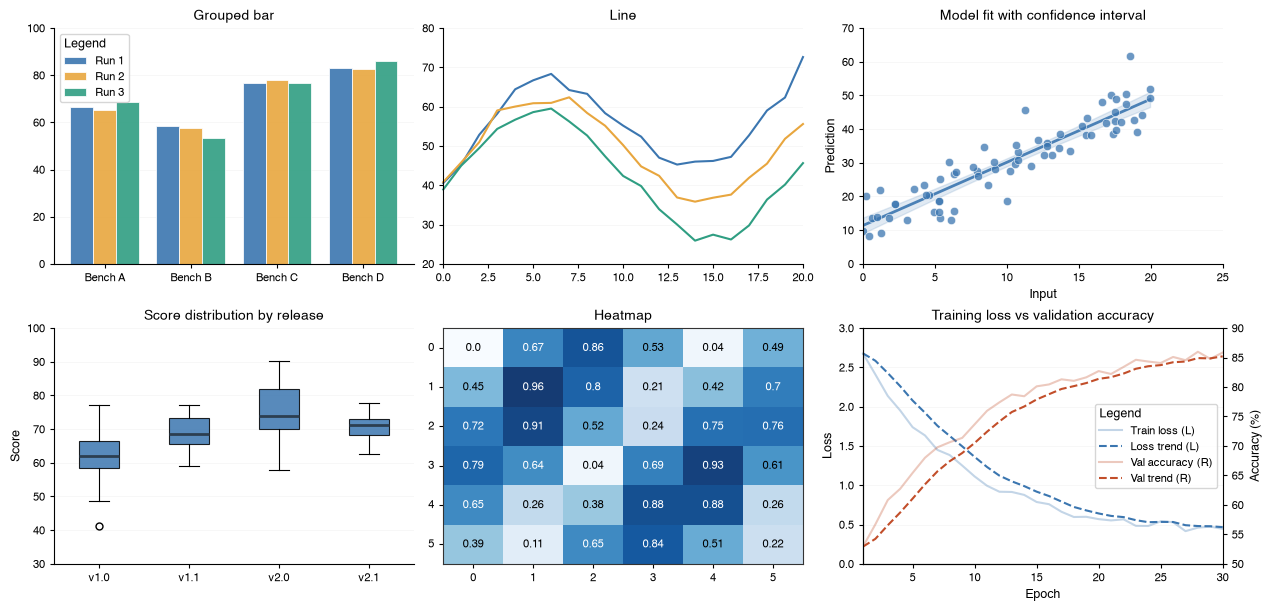

In [3]:
config.set_theme(THEME.DEFAULT)
show_swatches()
signature(pair=("#3B76B0", "#C24E2A")).show()


### Material

The Google hues in brand order, blue, red, yellow, green, cyan and violet, re-stepped in lightness so red and green stay apart for deutan readers; a bottom spine only and a light solid grid.

Selected with [`THEME.MATERIAL`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`MATERIAL_THEME`](../../../references/themes/#datachart.themes.MATERIAL_THEME).


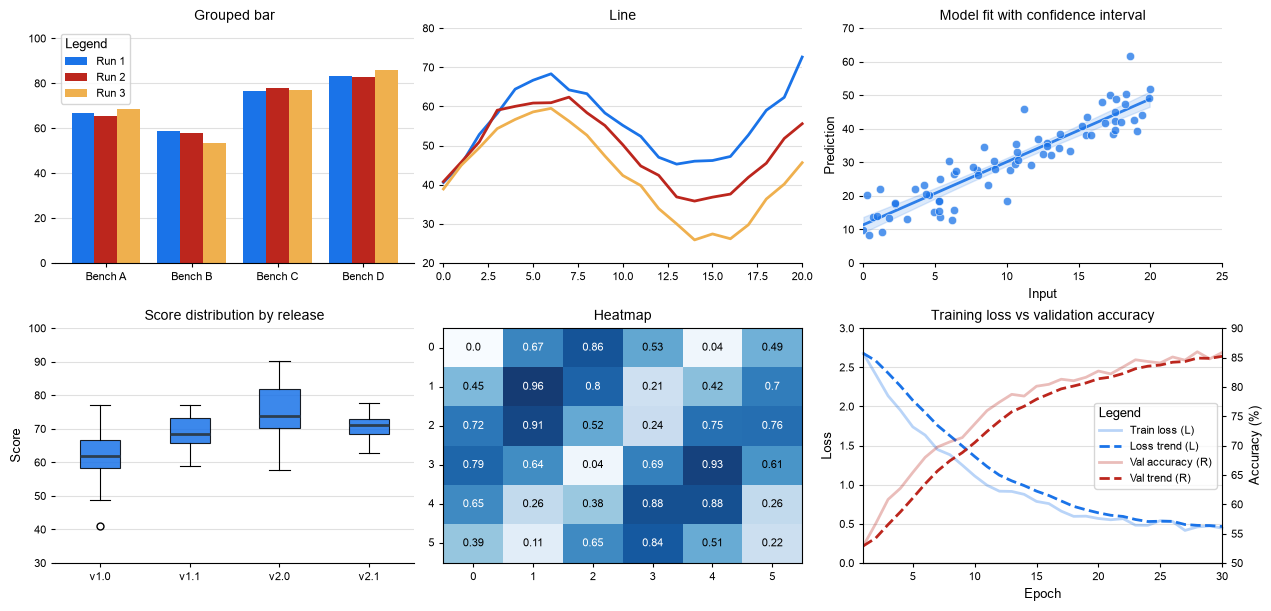

In [4]:
config.set_theme(THEME.MATERIAL)
show_swatches()
signature(pair=("#1A73E8", "#BC261D")).show()


### Minimal

Accent violet with five greys stepped in lightness, dark and light interleaved, no spines or tick marks, flat bars.

Selected with [`THEME.MINIMAL`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`MINIMAL_THEME`](../../../references/themes/#datachart.themes.MINIMAL_THEME).


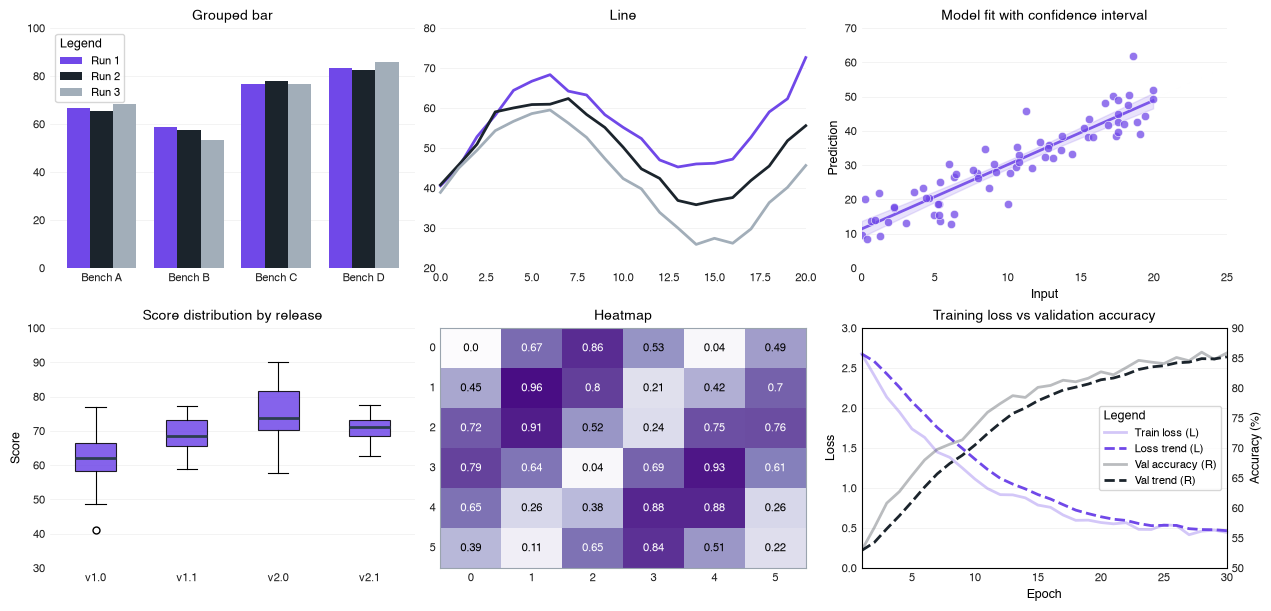

In [5]:
config.set_theme(THEME.MINIMAL)
show_swatches()
signature(pair=("#7048E8", "#1B242C")).show()


### Harbor

Navy to sky and amber to sand, stepped in lightness, with taupe and near-black closing the set. Two hue families keep the chart reading as one palette, and every pair of series stays apart for deutan, protan and tritan readers.

Built as `derive_theme(THEME.DEFAULT, lead=COLORS.Harbor, traits=[TRAIT.FLAT])` with the Cividis value scale. Selected with [`THEME.HARBOR`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`HARBOR_THEME`](../../../references/themes/#datachart.themes.HARBOR_THEME).


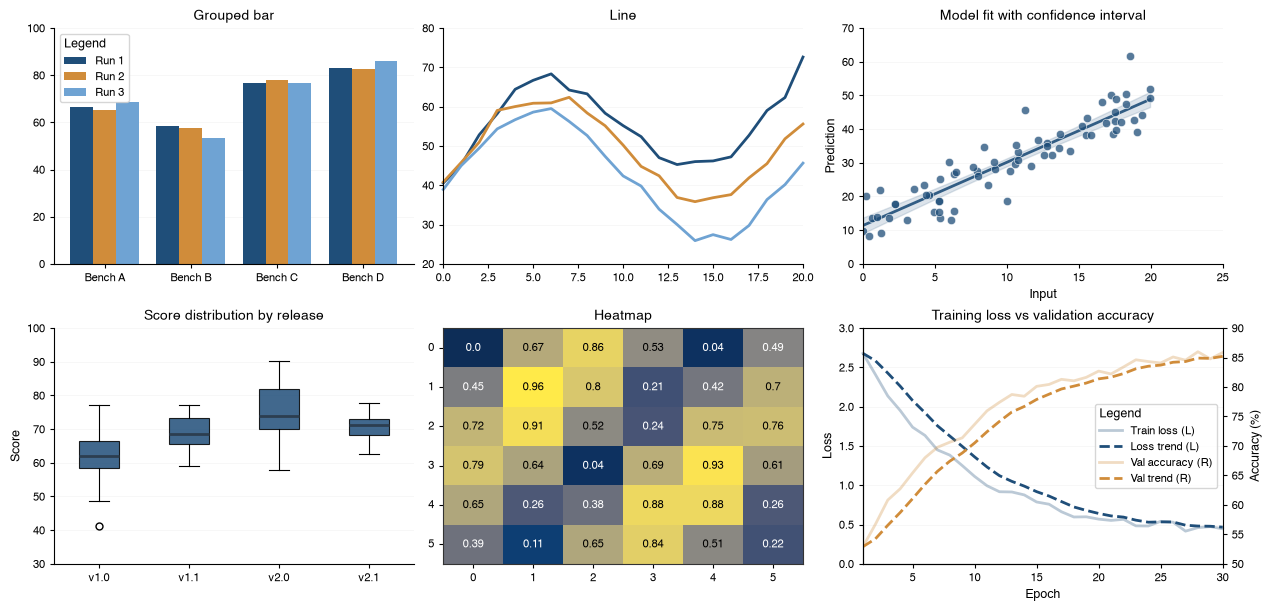

In [6]:
config.set_theme(THEME.HARBOR)
show_swatches()
signature(pair=("#1F4E79", "#D08C3A")).show()


### Dark

Azure, amber, mint, rose, violet and a near-white, each lifted clear of the
page, on a near-black figure with the plotting area a step lighter. Every
furniture colour — spines, ticks, fonts, grid, legend frame, value labels,
annotation boxes, heatmap frame and separators — carries a light counterpart,
so the theme is complete without a single override. The value scale is
Viridis, which reads dark to light and so rises off the panel. A heatmap cell
label still follows its own cell, so a light cell keeps dark text.

Selected with [`THEME.DARK`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`DARK_THEME`](../../../references/themes/#datachart.themes.DARK_THEME).


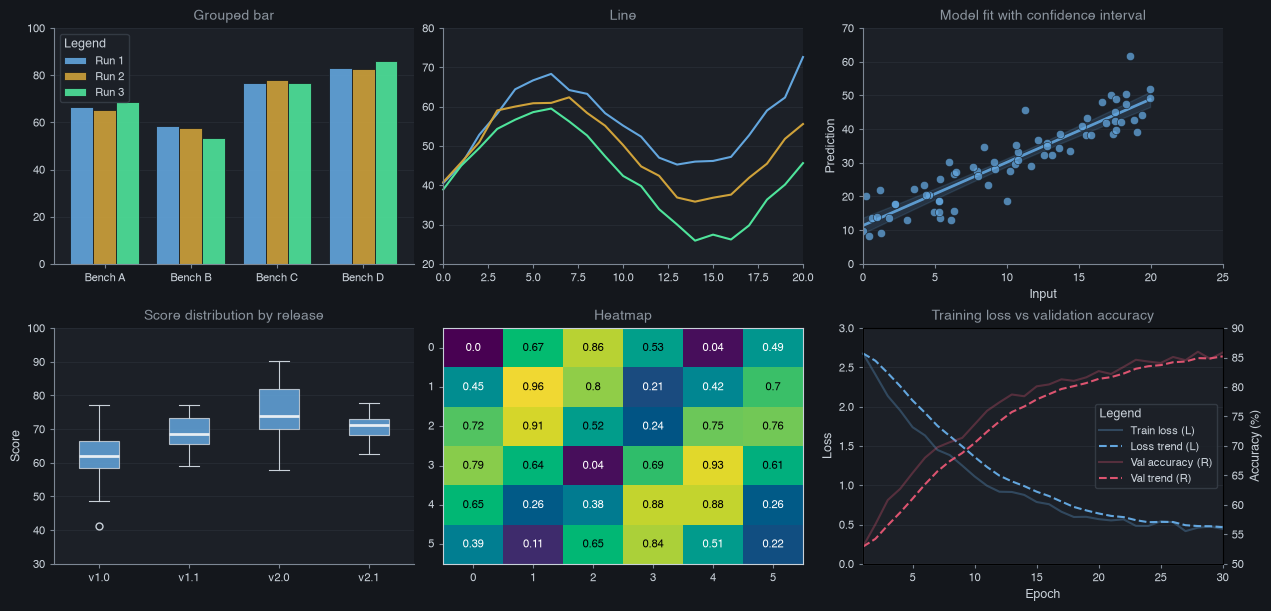

In [7]:
config.set_theme(THEME.DARK)
show_swatches()
signature(pair=("#63A6DE", "#DC5470")).show()


## Print and black-and-white

Themes that survive a greyscale printer or photocopier: greys with pattern cycles, navy ink over lightness-stepped blues and greens, hatches over muted print tones, and four whose colours stay apart for colour-blind readers and carry dashes, markers or hatches for the greyscale print.


### Greyscale

Five slate greys 0.16 apart in lightness, with hatch, dash and marker cycles so a sixth series still differs on paper; the same open spines and muted grid treatment.

Selected with [`THEME.GREYSCALE`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`GREYSCALE_THEME`](../../../references/themes/#datachart.themes.GREYSCALE_THEME).


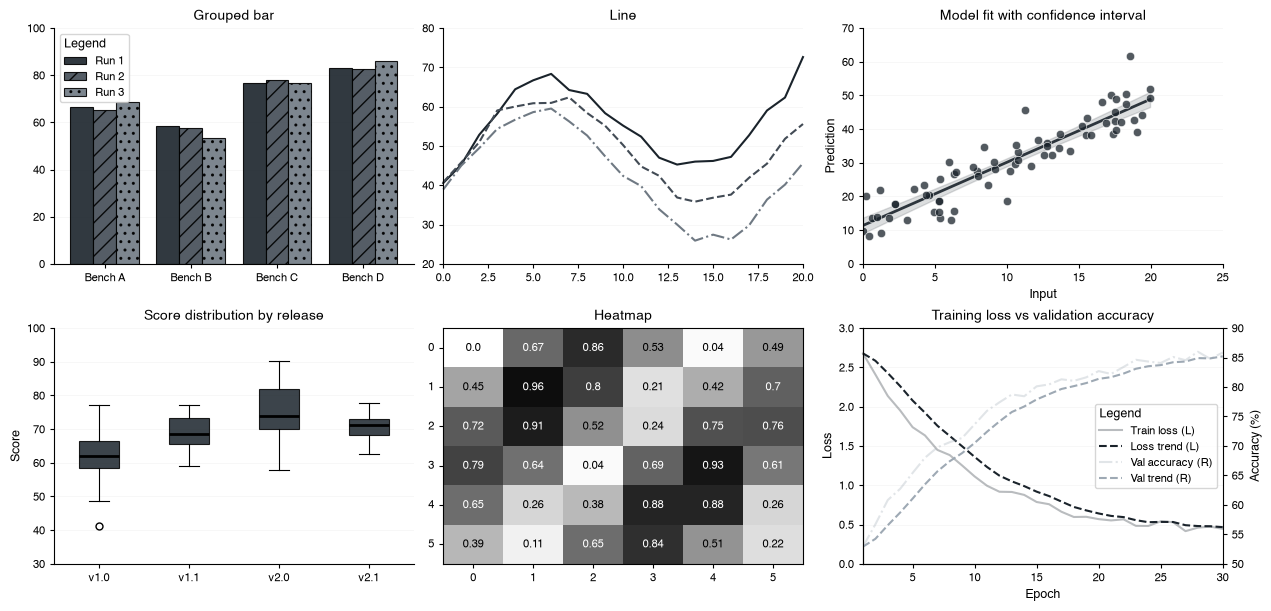

In [8]:
config.set_theme(THEME.GREYSCALE)
show_swatches()
signature(pair=("#1A232B", "#9EA9B4")).show()


### Ink

Five YlGnBu samples stepped in lightness (`COLORS.PaperYlGnBu`), darkest and lightest first, with navy ink edges, print-ready.

Selected with [`THEME.INK`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`INK_THEME`](../../../references/themes/#datachart.themes.INK_THEME).


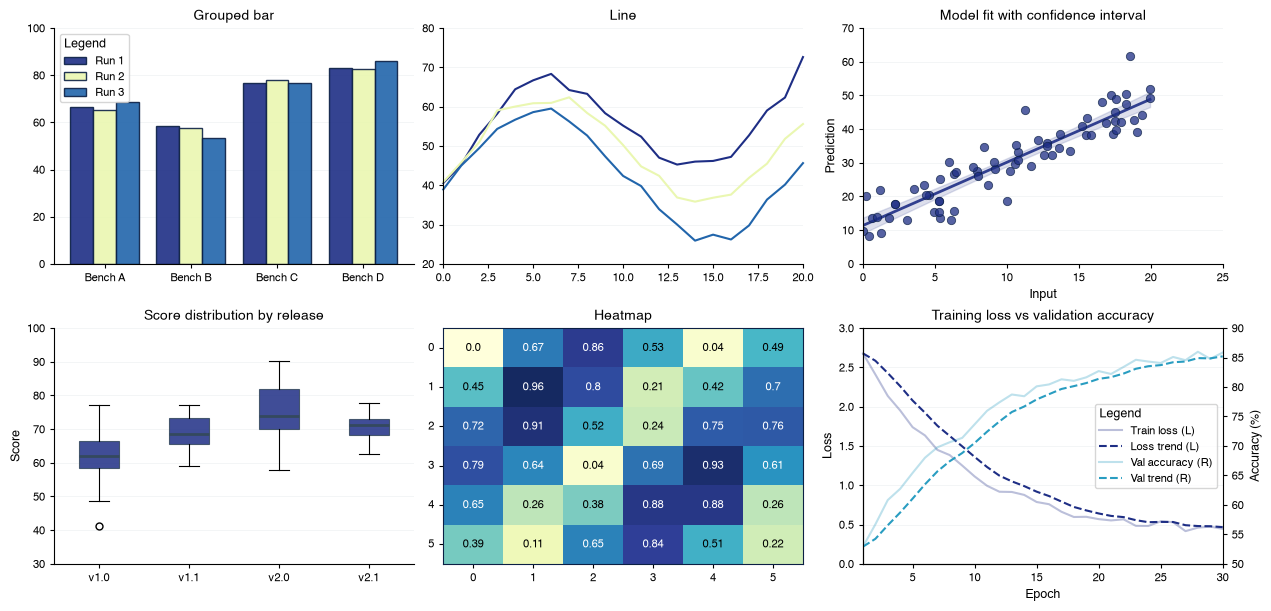

In [9]:
config.set_theme(THEME.INK)
show_swatches()
signature(pair=("#1E2E85", "#299DC1")).show()


### Hatch

Black edges, dotted grid, and a six-entry hatch cycle applied per bar series, so grouped bars stay distinguishable in black-and-white print; the green sits deep so it stays apart from rust for deutan readers.

Built as `derive_theme(THEME.DEFAULT, lead=COLORS.Rust, traits=[TRAIT.HATCHED, TRAIT.OUTLINED])` with the YlOrBr value scale, a dotted grid and the ink font stack. Selected with [`THEME.HATCH`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`HATCH_THEME`](../../../references/themes/#datachart.themes.HATCH_THEME).


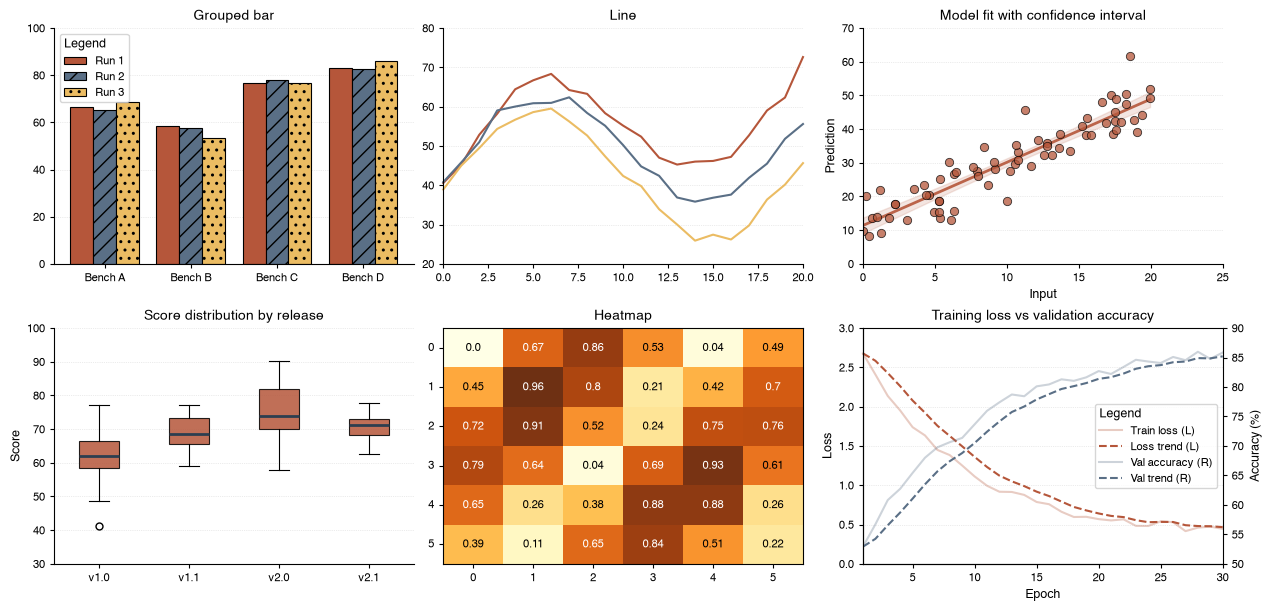

In [10]:
config.set_theme(THEME.HATCH)
show_swatches()
signature(pair=("#B5563A", "#5A6F86")).show()


### Muted

Indigo, cyan, sand, rose and wine from Paul Tol's muted scheme, every pair distinct for deutan, protan and tritan readers. Lines also differ by dash and scatter points by marker, bars carry black edges and the grid is dotted, so a figure survives a greyscale print.

Built as `derive_theme(THEME.DEFAULT, lead=COLORS.TolMuted, traits=[TRAIT.PATTERNED, TRAIT.EDGED])` with the YlOrBr value scale and a dotted grid. Selected with [`THEME.MUTED`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`MUTED_THEME`](../../../references/themes/#datachart.themes.MUTED_THEME).


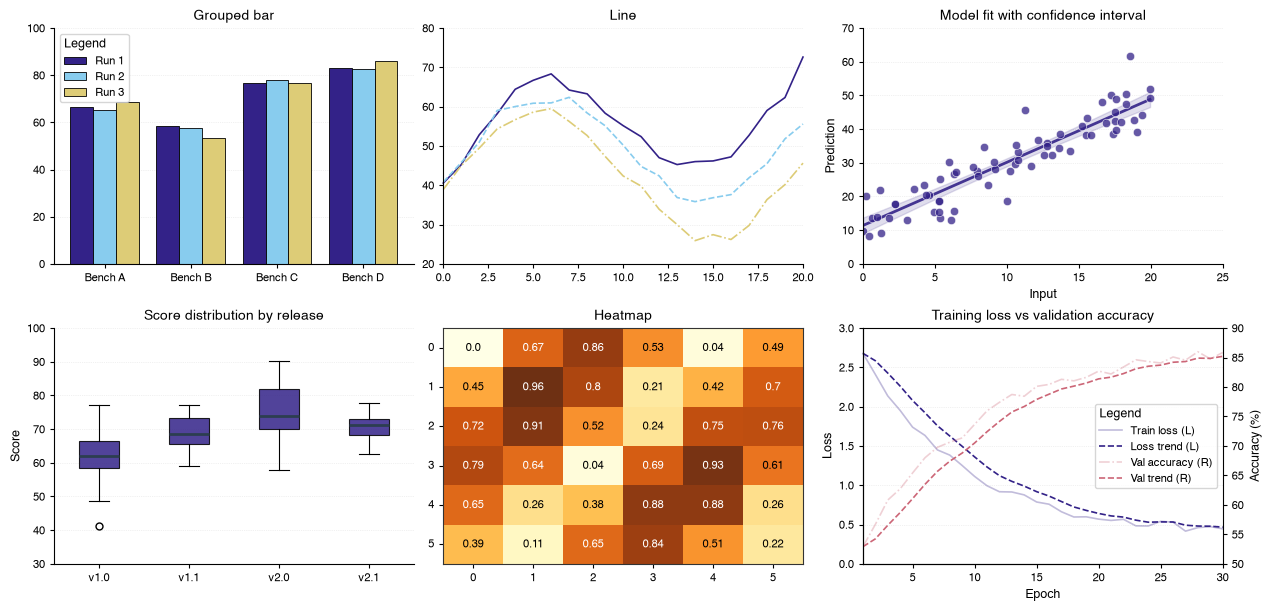

In [11]:
config.set_theme(THEME.MUTED)
show_swatches()
signature(pair=("#332288", "#CC6677")).show()


### Contrast

Navy, straw, dusty rose, charcoal and grey, each a clear lightness step from the next, so a photocopy still tells the series apart; bars take a hatch cycle and black edges, lines a dash cycle, scatter points a marker cycle.

Built as `derive_theme(THEME.DEFAULT, lead=COLORS.Contrast, traits=[TRAIT.PATTERNED, TRAIT.HATCHED])` with the Cividis value scale. Selected with [`THEME.CONTRAST`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`CONTRAST_THEME`](../../../references/themes/#datachart.themes.CONTRAST_THEME).


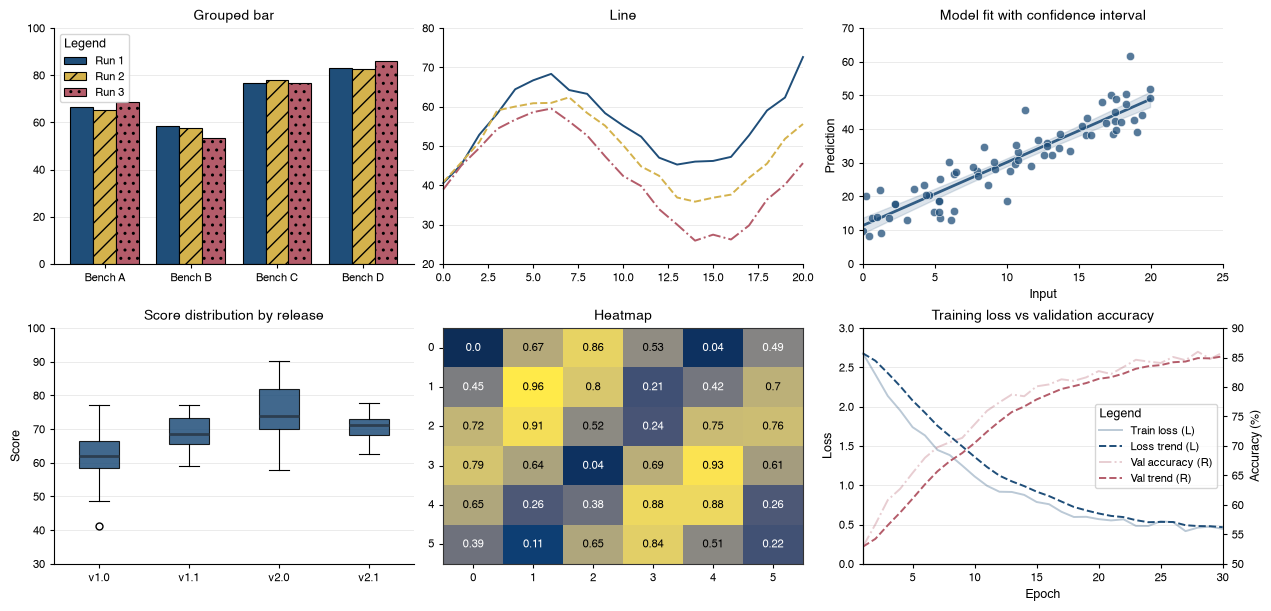

In [12]:
config.set_theme(THEME.CONTRAST)
show_swatches()
signature(pair=("#1F4E79", "#B45C6A")).show()


### Muted hatch

The five muted colours of `MUTED` under the hatch cycle of `CONTRAST`, so bars survive a greyscale print by pattern as well as colour. The value scale is BuPu, the family of indigo and wine, instead of YlOrBr.

Built as `derive_theme(THEME.DEFAULT, lead=COLORS.TolMuted, traits=[TRAIT.PATTERNED, TRAIT.HATCHED])` with the BuPu value scale and a dotted grid. Selected with [`THEME.MUTEDHATCH`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`MUTEDHATCH_THEME`](../../../references/themes/#datachart.themes.MUTEDHATCH_THEME).

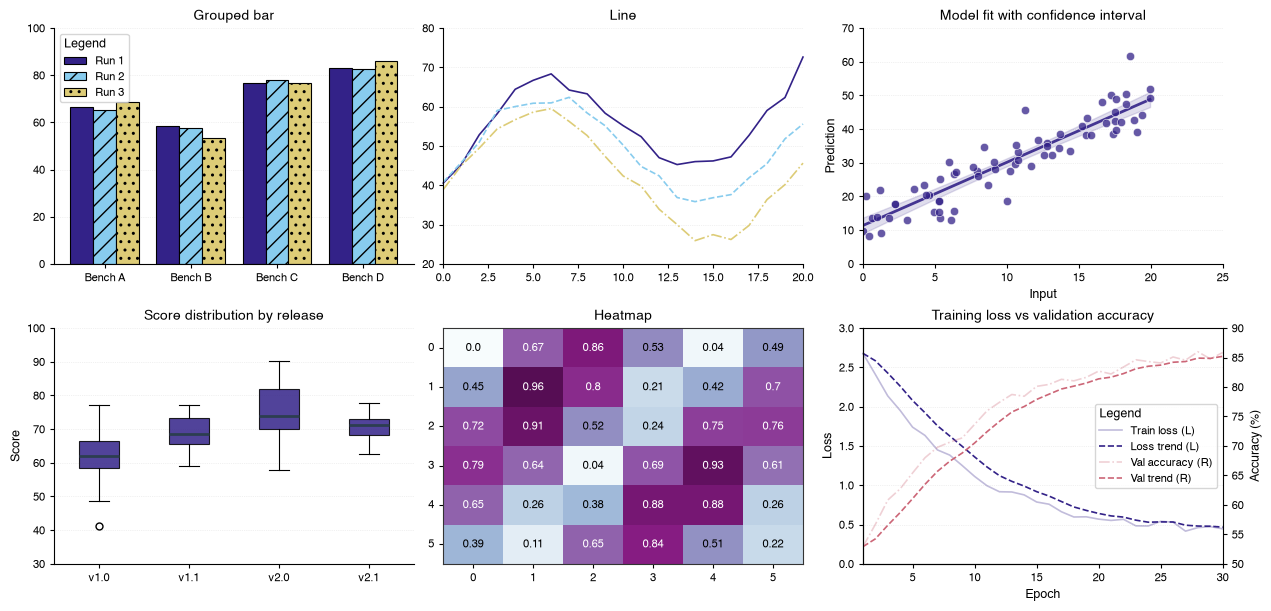

In [13]:
config.set_theme(THEME.MUTEDHATCH)
show_swatches()
signature(pair=("#332288", "#CC6677")).show()

### Slate hatch

The `HATCH` theme without rust: slate blue, sand, wine, green, orchid and sky blue under black edges, hatches and a dotted grid, every pair distinct for deutan and protan readers. The value scale is PuBu.

Built as `derive_theme(THEME.DEFAULT, lead=COLORS.Slate, traits=[TRAIT.HATCHED, TRAIT.OUTLINED])` with the PuBu value scale and the hatch theme's grid and fonts. Selected with [`THEME.SLATEHATCH`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`SLATEHATCH_THEME`](../../../references/themes/#datachart.themes.SLATEHATCH_THEME).

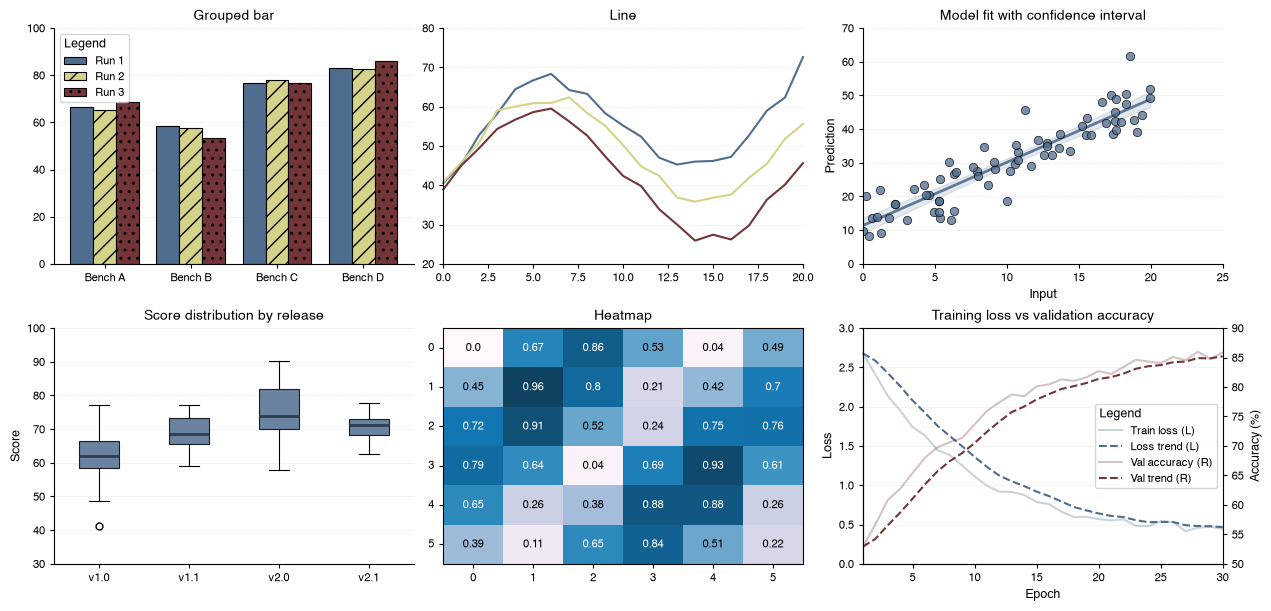

In [14]:
config.set_theme(THEME.SLATEHATCH)
show_swatches()
signature(pair=("#4F6D8F", "#743538")).show()

## Illustrative

Hand-drawn looks for explainers, blog posts and talks, where a chart should read as a drawing rather than a measurement.


### Sketch

Hand-drawn: wobbled paths, series lines cut out by a white halo, thick spines and lines, no grid, and the Comic Neue font, downloaded on first use, so the look is the same on every machine. The wobble and halo are theme attributes applied at render time, so nothing changes in matplotlib's global settings; the halo sits under line, radial and regression lines only, and a chart's `style` can set `plot_sketch_halo_width` to `0` where many lines overlap. The green is greyed towards sage so it stays apart from vermilion for deutan readers.

Selected with [`THEME.SKETCH`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`SKETCH_THEME`](../../../references/themes/#datachart.themes.SKETCH_THEME).


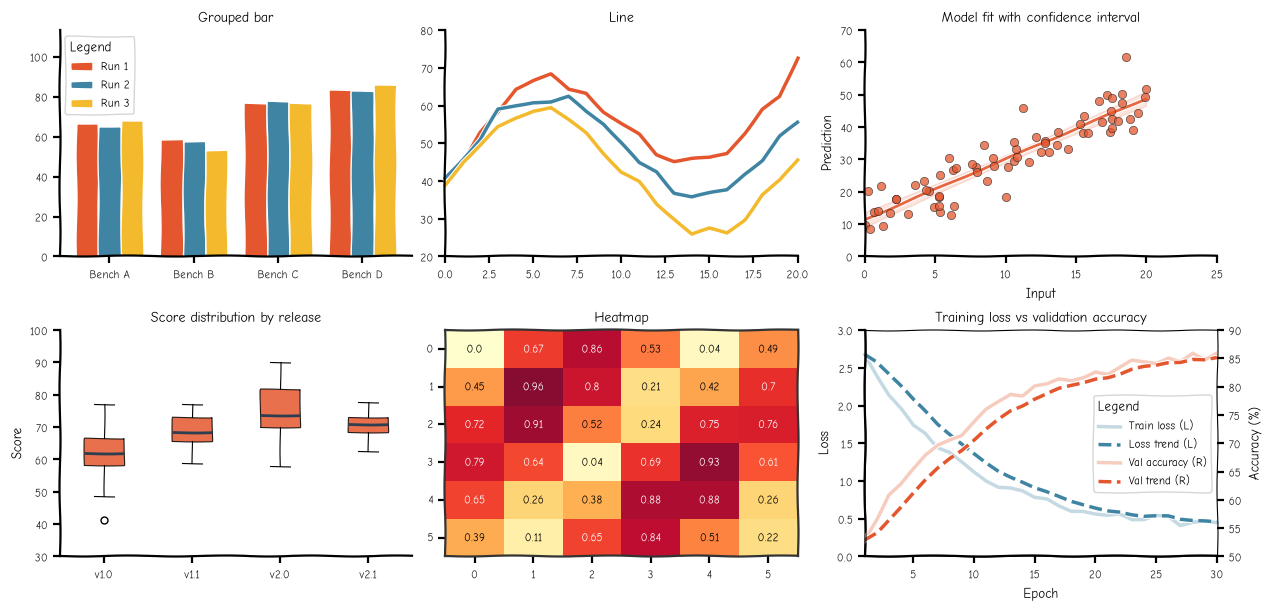

In [15]:
config.set_theme(THEME.SKETCH)
show_swatches()
signature(pair=("#3F84A3", "#E4572E")).show()


### Quill

Black ink on white paper, as a quill and an etching needle would draw it. There is one ink only, so series differ by line style, marker and etching, never by color. Series lines are broad-nib pen strokes whose width follows the pen's direction. Bars, areas and bodies are etched by hand instead of tiled with a hatch, with a faint ink wash under the bars and bodies. A value scale (heatmap, calendar, hexbin, filled contour) reads as steps of etch density; where a chart asks for a colorbar, a legend of the steps takes its place. Text is set in the IM Fell English font, downloaded on first use, titles in its italic. Like the sketch look, every effect is a theme attribute applied at render time, so nothing changes in matplotlib's global settings.

Selected with [`THEME.QUILL`](../../../references/constants/#datachart.constants.THEME); the full attribute set is [`QUILL_THEME`](../../../references/themes/#datachart.themes.QUILL_THEME).


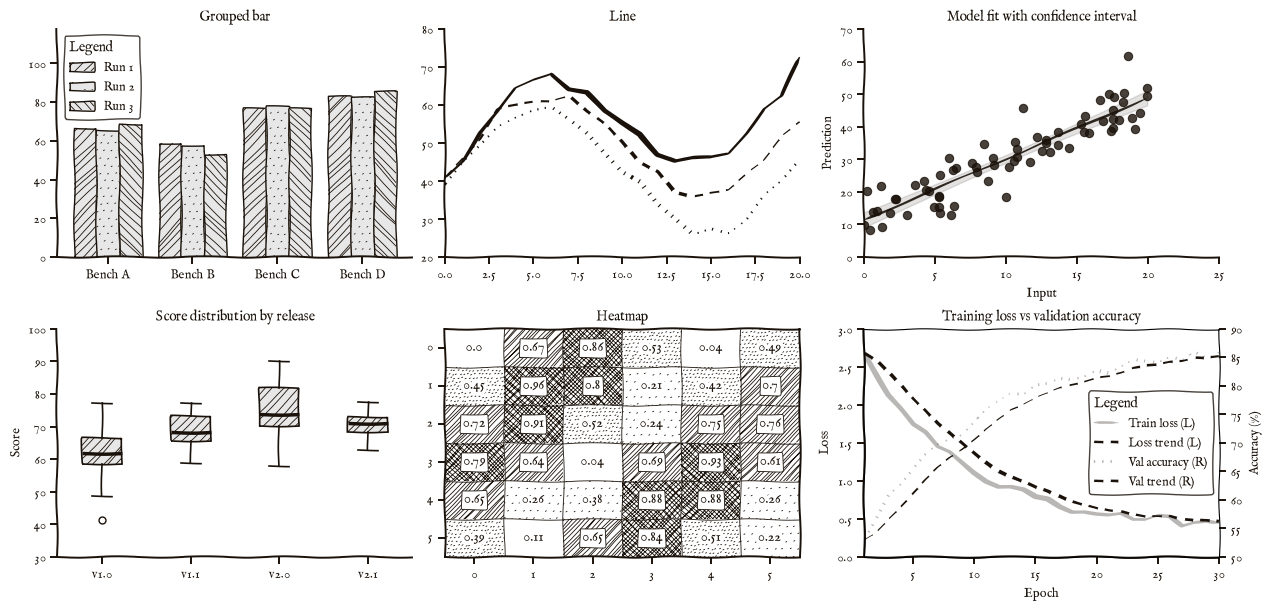

In [16]:
config.set_theme(THEME.QUILL)
show_swatches()
signature(pair=("#1A120A", "#1A120A")).show()


---

Applying a theme replaces the whole global configuration, so remember to call
`config.set_theme(...)` (or `config.reset_config()`) before building the charts
it should style. See the [themes how-to](../themes/) for customizing themes
attribute by attribute.


In [17]:
config.reset_config()
